# Orbital Debris Database: Exploring the Landscape

**Database:** orbital_debris.db (SQLite)  
**Docs:** See quick reports in notebook 04 and data dictionary in `docs/schema` for full schema and field definitions.

**Goal:** Surface patterns, outliers, and new questions in the orbital debris database to guide deeper analysis and visualization.

### Why this notebook?
This notebook builds on the cleaned, joined database. Instead of repeating full audits, it focuses on targeted exploration, query prototyping, and visual storytelling to support research questions and analysis.

### What we do here
1. **Prototype questions:** Use SQL and pandas to dig into specific trends, outliers, or hypotheses.
2. **Visualize:** Create quick charts to spot patterns and inform next steps.
3. **Document findings:** Save useful queries, charts, and notes for future reference.

*For table structure, nulls, and sample data, see the end of notebook 04 and the data dictionary.*

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3 as sql
import utility as utils
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, Markdown
 
pd.set_option('display.max_columns', None)
 
# Visualization: high-contrast palette, dark background
sns.set_palette("plasma")
plt.style.use('dark_background')
plt.rcParams.update({
    "grid.alpha": 0.2,
    "axes.facecolor": "black",
    "figure.facecolor": "black",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "legend.facecolor": "black",
    "legend.edgecolor": "white"
})
 
orbital_debris_conn = sql.connect('../data/clean/orbital_debris.db')

**Note:** Full quick reports for all database tables are generated at the end of notebook 04 (`04_orbital_debris_synthesis.ipynb`). See that notebook for detailed table structure, nulls, and sample data. For field definitions and schema details, refer to the data dictionary in `docs/schema`. This notebook focuses on exploration and analysis.

### Launch Year Trends: Decoupling Point in Orbital Growth
 
**Intent:** Identify when orbital object growth shifted from linear to exponential by visualizing launches per year.
 
**Method:**
- Query the satellites table for launch years.
- Count and plot the number of objects launched per year.
- Visually inspect for inflection points or rapid growth phases.
 
*Reference: Checklist Item 1.1*

In [2]:
# Query: Launches per year
launches_per_year_query = """
SELECT
    satellites.norad_id,
    satellites.object_name,
    launch_events.launch_date,
    launch_events.launch_site
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_launches_per_year = pd.read_sql_query(launches_per_year_query, orbital_debris_conn)

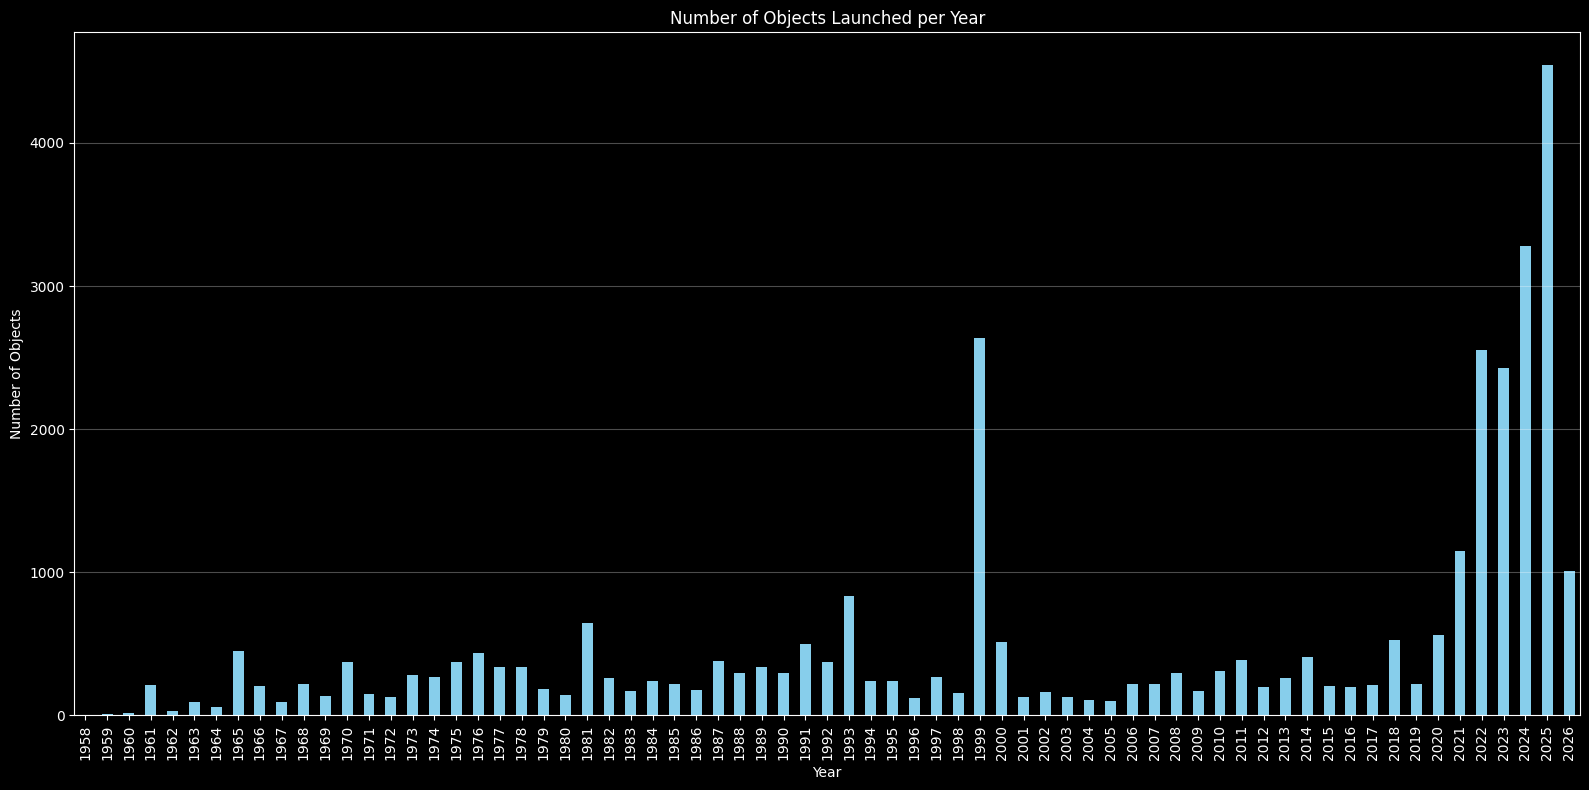

In [3]:
# Convert to datetime and extract year
df_launches_per_year['launch_year'] = pd.to_datetime(df_launches_per_year['launch_date'], errors='coerce').dt.year

# Count launches per year
launch_counts = df_launches_per_year['launch_year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(16,8))
launch_counts.plot(kind='bar', color='skyblue')

plt.title('Number of Objects Launched per Year')
plt.xlabel('Year')
plt.ylabel('Number of Objects')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../charts/questions/exploratory/svg/launches_per_year_exp.svg', bbox_inches='tight')
plt.savefig('../charts/questions/exploratory/png/launches_per_year_exp.png', bbox_inches='tight', dpi=300)
plt.show()

In [4]:
# Validation: Check for nulls, unique years, and overall data integrity
print('Row count:', len(df_launches_per_year))
display(df_launches_per_year.head())
display(df_launches_per_year.tail())

print('Unique years:', df_launches_per_year["launch_year"].nunique())
print('Year range:', df_launches_per_year["launch_year"].min(), '-', df_launches_per_year["launch_year"].max())

print('Nulls per column:')
display(df_launches_per_year.isnull().sum())

print('Sample years:', df_launches_per_year["launch_year"].unique()[:10])

Row count: 33356


,norad_id,object_name,launch_date,launch_site,launch_year
0,5,VANGUARD 1,1958-03-17,AFETR,1958
1,16,VANGUARD R/B,1958-03-17,AFETR,1958
2,1576,VANGUARD DEB,1958-03-17,AFETR,1958
3,112,LUNA 1,1959-01-02,TYMSC,1959
4,11,VANGUARD 2,1959-02-17,AFETR,1959


,norad_id,object_name,launch_date,launch_site,launch_year
33351,68359,CENTISPACE-1 OBJECT K,2026-03-22,YSLA,2026
33352,68377,SUPERVIEW NEO-2 OBJECT A,2026-03-25,TAISC,2026
33353,68378,SUPERVIEW NEO-2 OBJECT B,2026-03-25,TAISC,2026
33354,68379,CZ-2D R/B,2026-03-25,TAISC,2026
33355,68405,OBJECT A,2026-03-27,JSC,2026


Unique years: 69
Year range: 1958 - 2026
Nulls per column:


norad_id       0
object_name    0
launch_date    0
launch_site    0
launch_year    0
dtype: int64

Sample years: [1958 1959 1960 1961 1962 1963 1964 1965 1966 1967]


### Debris Growth Over Time: Annual Debris Object Counts

**Intent:** Visualize the trend of debris objects in orbit by year to identify growth patterns and inflection points.

**Method:**
- Query the debris table (or filter satellites table for debris type) for object type = 'DEBRIS'.
- Extract/convert launch or identification year.
- Count and plot the number of debris objects per year.
- Validate row/column counts and check for missing years or anomalies.

*Reference: Checklist Item 1.2*

In [5]:
# Query: Debris objects per year
debris_query = """
SELECT
    satellites.norad_id,
    satellites.object_name,
    satellites.object_type,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE satellites.object_type = 'DEBRIS' AND launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_debris_per_year = pd.read_sql_query(debris_query, orbital_debris_conn)

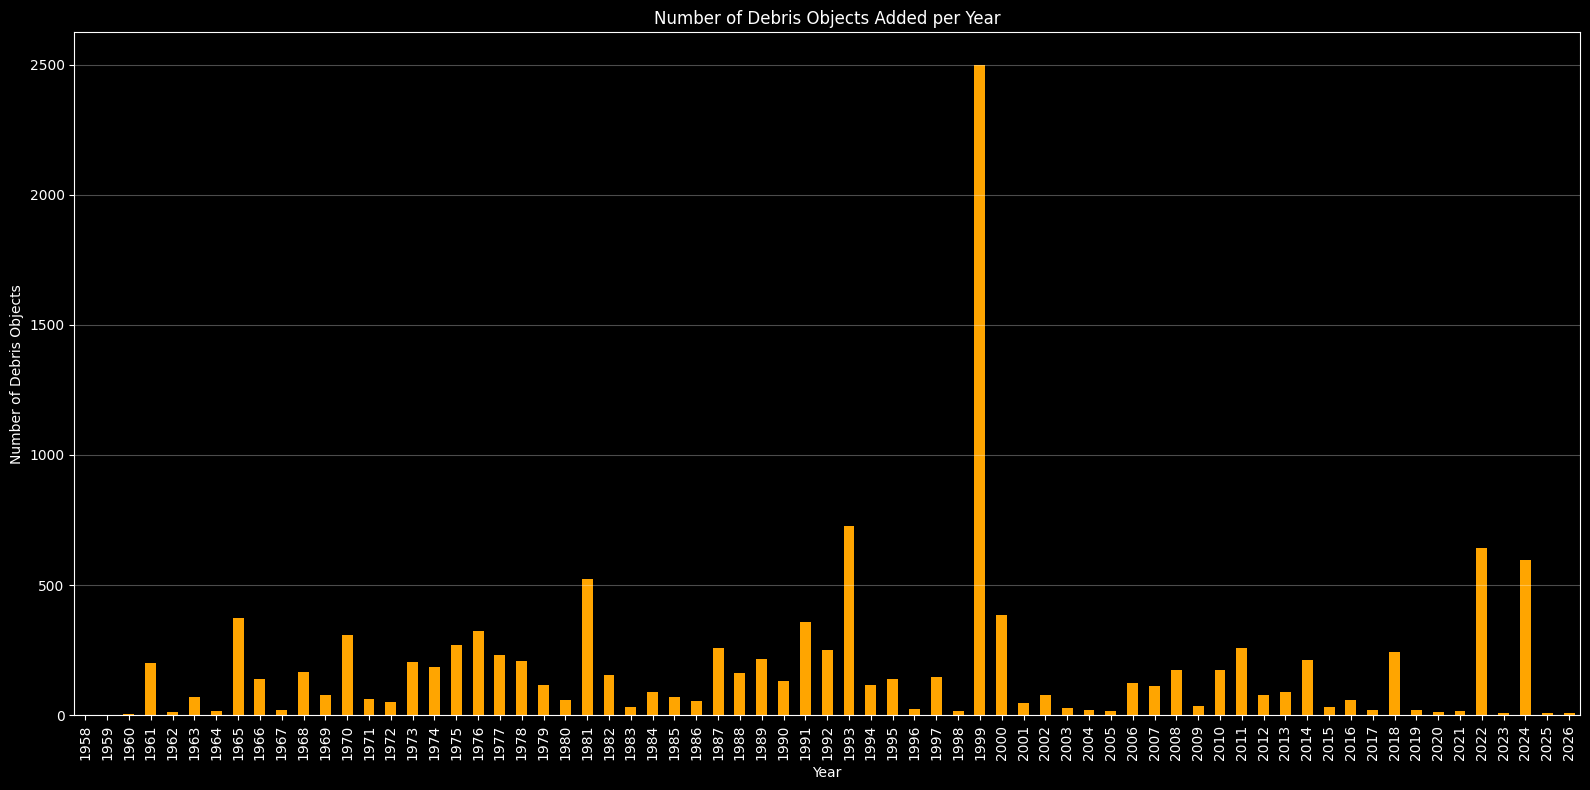

In [6]:
# Convert to datetime and extract year
df_debris_per_year['debris_year'] = pd.to_datetime(df_debris_per_year['launch_date'], errors='coerce').dt.year

# Count debris objects per year
debris_counts = df_debris_per_year['debris_year'].value_counts().sort_index()

plt.figure(figsize=(16,8))

debris_counts.plot(kind='bar', color='orange')

plt.title('Number of Debris Objects Added per Year')
plt.xlabel('Year')
plt.ylabel('Number of Debris Objects')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../charts/questions/exploratory/svg/debris_per_year_exp.svg', bbox_inches='tight')
plt.savefig('../charts/questions/exploratory/png/debris_per_year_exp.png', bbox_inches='tight', dpi=300)
plt.show()

In [7]:
# Validation: Debris Growth Data Integrity
print('Row count:', len(df_debris_per_year))
display(df_debris_per_year.head())
display(df_debris_per_year.tail())

print('Unique years:', df_debris_per_year["debris_year"].nunique())
print('Year range:', df_debris_per_year["debris_year"].min(), '-', df_debris_per_year["debris_year"].max())

print('Nulls per column:')
display(df_debris_per_year.isnull().sum())

print('Sample years:', df_debris_per_year["debris_year"].unique()[:10])

Row count: 12560


,norad_id,object_name,object_type,launch_date,debris_year
0,1576,VANGUARD DEB,DEBRIS,1958-03-17,1958
1,61446,VANGUARD DEB,DEBRIS,1959-02-17,1959
2,115,THOR ABLE DEB [YO],DEBRIS,1960-04-01,1960
3,51,ECHO 1 DEB [METAL OBJ],DEBRIS,1960-08-12,1960
4,52,ECHO 1 DEB [MYLAR OBJ],DEBRIS,1960-08-12,1960


,norad_id,object_name,object_type,launch_date,debris_year
12555,67692,CZ-2F DEB,DEBRIS,2026-02-07,2026
12556,67718,CZ-2F DEB,DEBRIS,2026-02-07,2026
12557,67719,CZ-2F DEB,DEBRIS,2026-02-07,2026
12558,67720,CZ-2F DEB,DEBRIS,2026-02-07,2026
12559,67763,VULCAN CENTAUR DEB,DEBRIS,2026-02-12,2026


Unique years: 69
Year range: 1958 - 2026
Nulls per column:


norad_id       0
object_name    0
object_type    0
launch_date    0
debris_year    0
dtype: int64

Sample years: [1958 1959 1960 1961 1962 1963 1964 1965 1966 1967]
